In [18]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

In [19]:
#define a state

class PasswordState(TypedDict):
    password: str
    has_uppercase: bool
    has_lowercase: bool
    has_digit: bool
    has_symbol: bool
    length: int
    strength: str
    score: int
    

In [20]:
#Function to check password strength

def check_password_strength(state: PasswordState) -> PasswordState:
    password = state["password"]
    length = len(password)
    
    has_upper = any(c.isupper() for c in password)
    has_lower = any(c.islower() for c in password)
    has_digit = any(c.isdigit() for c in password)
    has_symbol = any(not c.isalnum() for c in password)
    
    if length < 8:
        strength = "Weak"
    elif length < 12:
        strength = "Moderate"
    elif length < 16:
        strength = "Strong"
    else:
        strength = "Very Strong"
    
    return {
        "length": length,
        "has_uppercase": has_upper,
        "has_lowercase": has_lower,
        "has_digit": has_digit,
        "has_symbol": has_symbol,
        "strength": strength
    }
    

In [21]:
#function for scoring
def score_password(state: PasswordState) -> PasswordState:
    score = 0
    if state['has_uppercase']:
        score += 1
    if state['has_lowercase']:
        score += 1
    if state['has_digit']:
        score += 1
    if state['has_symbol']:
        score += 1
    if state['length'] >= 8:
        score += 1
    return {"score": score}

In [22]:
#define a graph

graph = StateGraph(PasswordState)

#add nodes
graph.add_node("check_password_strength", check_password_strength)
graph.add_node("check score", score_password)

#add edges
graph.add_edge(START, "check_password_strength")
graph.add_edge("check_password_strength", "check score")
graph.add_edge("check score", END)

#graph compilation
workflow = graph.compile()


In [27]:
workflow.invoke({
    "password": "MyP@ssw0rd123"
})

{'password': 'MyP@ssw0rd123',
 'has_uppercase': True,
 'has_lowercase': True,
 'has_digit': True,
 'has_symbol': True,
 'length': 13,
 'strength': 'Strong',
 'score': 5}

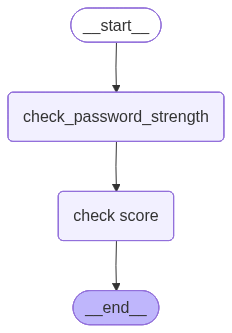

In [30]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())